# Machine Learning Modelling
## Predicting Complete Childhood Immunisation Using Machine Learning:
### Evidence from the Nigeria Demographic and Health Survey (NDHS)


**Dataset:** `immunisation_modelling_dataset.csv` (cleaned NDHS KR dataset)

**Purpose:** To train and compare multiple classification models for predicting complete childhood immunisation, using a preprocessing pipeline that preserves the data cleaning and feature choices established in the earlier notebooks.

## Notebook Outline

1. Initial Data Inspection
2. Feature Grouping & Train-Test Split
3. Preprocessing Pipeline
4. Logistic Regression (Baseline & Balanced)
5. Decision Tree
6. Random Forest
7. XGBoost
8. Support Vector Machine (SVM)
9. Final Model Comparison & Selection

In [23]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    OrdinalEncoder
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [24]:
df = pd.read_csv("immunisation_modelling_dataset.csv")

df.head()

,child_sex,birth_order,child_age_months,mother_age,mother_education,religion,ethnicity,wealth_index,residence,geopolitical_zone,mother_working,first_anc_month,anc_visits,place_of_delivery,distance_problem,household_size,fully_immunised,media_exposure
0,0,5,17,38,0,3,130,2,0,1,0,5,4,11,0,7,0,0
1,0,3,12,34,1,3,109,3,0,1,0,0,0,11,0,4,0,0
2,0,8,19,39,2,3,130,3,0,1,1,6,8,23,0,15,1,1
3,0,6,15,29,0,3,130,2,0,1,1,0,0,11,1,9,0,0
4,1,4,19,32,0,3,130,3,0,1,0,0,0,11,1,8,0,0


In [25]:
print("Dataset Shape:", df.shape)

Dataset Shape: (4527, 18)


In [26]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 1


In [27]:
df.dtypes

child_sex            int64
birth_order          int64
child_age_months     int64
mother_age           int64
mother_education     int64
religion             int64
ethnicity            int64
wealth_index         int64
residence            int64
geopolitical_zone    int64
mother_working       int64
first_anc_month      int64
anc_visits           int64
place_of_delivery    int64
distance_problem     int64
household_size       int64
fully_immunised      int64
media_exposure       int64
dtype: object

In [28]:
df["fully_immunised"].value_counts()

fully_immunised
0    3037
1    1490
Name: count, dtype: int64

In [29]:
round(df["fully_immunised"].value_counts(normalize=True)*100,2)

fully_immunised
0    67.09
1    32.91
Name: proportion, dtype: float64

## Initial Data Inspection

The modelling dataset was successfully loaded and inspected.

The inspection confirmed:

- The dataset contains **4,527 observations** and **18 variables** — the original 16 plus two additional predictors (`distance_problem`, `household_size`) added after testing candidates from the wider literature for association with the outcome.
- No missing values were present.
- One duplicate records were retained because they represent valid survey respondents rather than repeated observations.
- All variables were correctly stored as integer values suitable for machine learning.
- The target variable (`fully_immunised`) remains moderately imbalanced, with approximately 67% not fully immunised and 33% fully immunised.

In [30]:
# ============================================================
# CREATE ETHNICITY GROUP (reduces cardinality before encoding)
# ============================================================
# Raw 'ethnicity' has 25+ distinct DHS codes, stored as numbers.
# One-hot encoding it directly blows up the feature space (213
# columns from 16 original) and creates many very sparse columns.
# Grouping into the top 10 most frequent ethnicities + "Others"
# mirrors the approach already used in NDHS_EDA.ipynb.
#
# IMPORTANT: every value is converted to a string (str(x)) here,
# not just the "Others" rows. Without this, the column ends up
# with a mix of numeric codes and the text "Others" in the same
# column, which OneHotEncoder cannot sort.

top_ethnicities = df["ethnicity"].value_counts().nlargest(10).index

df["ethnicity_group"] = df["ethnicity"].apply(
    lambda x: str(x) if x in top_ethnicities else "Others"
)

print("Original ethnicity categories:", df["ethnicity"].nunique())
print("Grouped ethnicity categories:", df["ethnicity_group"].nunique())
df["ethnicity_group"].value_counts()

Original ethnicity categories: 194
Grouped ethnicity categories: 11


ethnicity_group
130       1447
Others    1179
138        561
109        486
298        368
179        111
276         94
237         75
996         71
140         69
137         66
Name: count, dtype: int64

In [31]:
# ============================================================
# CREATE PLACE OF DELIVERY GROUP (same cardinality issue as ethnicity)
# ============================================================
# Raw 'place_of_delivery' has ~20 DHS facility-type codes, most with
# very few observations (e.g. "Mobile clinic" = 6 children, "Other
# private" = 4). One-hot encoding this directly adds many sparse
# columns for essentially no signal. Grouped into 5 categories using
# the same mapping already applied to the labelled EDA dataset in
# DHS_Project.ipynb, so both datasets use a consistent definition.

delivery_map = {
    11: "Home", 12: "Home",
    21: "Public facility", 22: "Public facility", 23: "Public facility",
    24: "Public facility", 25: "Public facility", 26: "Public facility",
    27: "Public facility",
    31: "Private facility", 32: "Private facility", 33: "Private facility",
    34: "Private facility", 35: "Private facility", 36: "Private facility",
    37: "Private facility", 38: "Private facility",
    41: "Faith-based facility", 42: "Faith-based facility",
    46: "Faith-based facility",
    96: "Other"
}

df["place_of_delivery_group"] = df["place_of_delivery"].map(delivery_map)

print("Original place_of_delivery categories:", df["place_of_delivery"].nunique())
print("Grouped place_of_delivery categories:", df["place_of_delivery_group"].nunique())
df["place_of_delivery_group"].value_counts()

Original place_of_delivery categories: 21
Grouped place_of_delivery categories: 5


place_of_delivery_group
Home                    2467
Public facility         1253
Private facility         735
Faith-based facility      41
Other                     31
Name: count, dtype: int64

In [32]:
# Target
target = "fully_immunised"

# Features
X = df.drop(columns=target)
y = df[target]

In [33]:
binary_features = [
    "child_sex",
    "residence",
    "mother_working",
    "distance_problem"
]

In [34]:
ordinal_features = [
    "mother_education",
    "wealth_index",
    "media_exposure"
]

In [35]:
nominal_features = [
    "religion",
    "ethnicity_group",
    "geopolitical_zone",
    "place_of_delivery_group"
]

In [36]:
numeric_features = [
    "birth_order",
    "child_age_months",
    "mother_age",
    "first_anc_month",
    "anc_visits",
    "household_size"
]

In [37]:
print("Binary:", len(binary_features))
print("Ordinal:", len(ordinal_features))
print("Nominal:", len(nominal_features))
print("Numeric:", len(numeric_features))

print("Total features:",
      len(binary_features)
      + len(ordinal_features)
      + len(nominal_features)
      + len(numeric_features))

Binary: 4
Ordinal: 3
Nominal: 4
Numeric: 6
Total features: 17


In [38]:
selected_features = binary_features + ordinal_features + nominal_features + numeric_features

X = df[selected_features]   # instead of df.drop(columns="fully_immunised")
y = df["fully_immunised"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [40]:
#verify split
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3621, 17)
X_test : (906, 17)
y_train: (3621,)
y_test : (906,)


In [41]:
print("Training Target Distribution")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Target Distribution")
print(y_test.value_counts(normalize=True) * 100)

Training Target Distribution
fully_immunised
0    67.080917
1    32.919083
Name: proportion, dtype: float64

Testing Target Distribution
fully_immunised
0    67.108168
1    32.891832
Name: proportion, dtype: float64


## Train-Test Split

The dataset was divided into training (80%) and testing (20%) subsets using a stratified random sampling approach.

Stratification was applied to preserve the class distribution of the target variable (`fully_immunised`) in both subsets, ensuring that the proportion of fully and not fully immunised children remained consistent across the training and testing datasets.

A fixed random state (`random_state=42`) was used to ensure reproducibility of the results.

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        # Scale numerical variables
        ("num", StandardScaler(), numeric_features),

        # One-Hot Encode nominal variables
        ("nom", OneHotEncoder(handle_unknown="ignore"), nominal_features),

        # Keep binary variables unchanged
        ("bin", "passthrough", binary_features),

        # Keep ordinal variables unchanged
        ("ord", "passthrough", ordinal_features)
    ]
)

In [44]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [45]:
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (3621, 39)
Processed testing shape : (906, 39)


In [46]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
feature_names

Number of processed features: 39


array(['num__birth_order', 'num__child_age_months', 'num__mother_age',
       'num__first_anc_month', 'num__anc_visits', 'num__household_size',
       'nom__religion_1', 'nom__religion_2', 'nom__religion_3',
       'nom__religion_4', 'nom__ethnicity_group_109',
       'nom__ethnicity_group_130', 'nom__ethnicity_group_137',
       'nom__ethnicity_group_138', 'nom__ethnicity_group_140',
       'nom__ethnicity_group_179', 'nom__ethnicity_group_237',
       'nom__ethnicity_group_276', 'nom__ethnicity_group_298',
       'nom__ethnicity_group_996', 'nom__ethnicity_group_Others',
       'nom__geopolitical_zone_1', 'nom__geopolitical_zone_2',
       'nom__geopolitical_zone_3', 'nom__geopolitical_zone_4',
       'nom__geopolitical_zone_5', 'nom__geopolitical_zone_6',
       'nom__place_of_delivery_group_Faith-based facility',
       'nom__place_of_delivery_group_Home',
       'nom__place_of_delivery_group_Other',
       'nom__place_of_delivery_group_Private facility',
       'nom__place_of_deli

In [47]:
# ==========================================================
# MASTER RESULTS DICTIONARY
# ==========================================================

results = {}

In [48]:
# ==========================================================
# FUNCTION TO STORE MODEL RESULTS
# ==========================================================

def store_results(model_name,
                  accuracy,
                  precision,
                  recall,
                  f1,
                  roc_auc):

    results[model_name] = {
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    }

## Logistic Regression (Baseline & Balanced)

In [49]:
from sklearn.linear_model import LogisticRegression

# Baseline Logistic Regression
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model
log_reg.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [50]:
# Predictions
y_pred = log_reg.predict(X_test_processed)

# Predicted probabilities
y_prob = log_reg.predict_proba(X_test_processed)[:, 1]

In [51]:
# ==========================================================
# EVALUATE BASELINE LOGISTIC REGRESSION
# ==========================================================

accuracy_lr = accuracy_score(y_test, y_pred)
precision_lr = precision_score(y_test, y_pred)
recall_lr = recall_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred)
roc_auc_lr = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1-score :", round(f1_lr, 4))
print("ROC-AUC  :", round(roc_auc_lr, 4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# Store results
store_results(
    "Baseline Logistic Regression",
    accuracy_lr,
    precision_lr,
    recall_lr,
    f1_lr,
    roc_auc_lr
)

Accuracy : 0.6545
Precision: 0.4599
Recall   : 0.2886
F1-score : 0.3546
ROC-AUC  : 0.6802

Classification Report

              precision    recall  f1-score   support

           0       0.71      0.83      0.76       608
           1       0.46      0.29      0.35       298

    accuracy                           0.65       906
   macro avg       0.58      0.56      0.56       906
weighted avg       0.62      0.65      0.63       906



In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.83      0.76       608
           1       0.46      0.29      0.35       298

    accuracy                           0.65       906
   macro avg       0.58      0.56      0.56       906
weighted avg       0.62      0.65      0.63       906



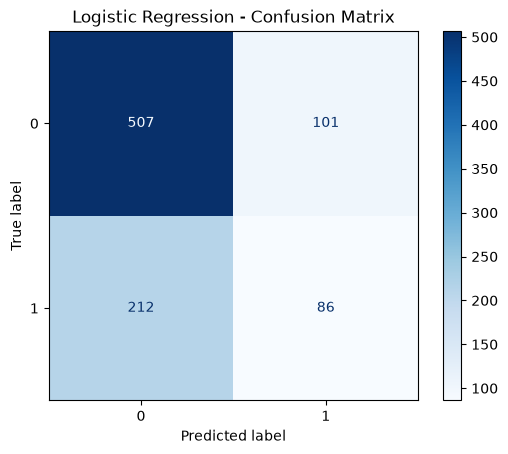

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [54]:
# Import the Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression model
# class_weight='balanced' gives more importance to the minority class
# max_iter=1000 ensures the algorithm has enough iterations to converge
# random_state=42 ensures reproducibility
log_reg_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [55]:
# Train the model using the processed training data
log_reg_balanced.fit(X_train_processed, y_train)


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [56]:
# Predict the class labels on the test set
y_pred_balanced = log_reg_balanced.predict(X_test_processed)

# Predict probabilities for ROC-AUC calculation
y_prob_balanced = log_reg_balanced.predict_proba(X_test_processed)[:, 1]

In [57]:
# ==========================================================
# EVALUATE BALANCED LOGISTIC REGRESSION
# ==========================================================

accuracy_bal_lr = accuracy_score(y_test, y_pred_balanced)
precision_bal_lr = precision_score(y_test, y_pred_balanced)
recall_bal_lr = recall_score(y_test, y_pred_balanced)
f1_bal_lr = f1_score(y_test, y_pred_balanced)
roc_auc_bal_lr = roc_auc_score(y_test, y_prob_balanced)

print("Accuracy :", round(accuracy_bal_lr, 4))
print("Precision:", round(precision_bal_lr, 4))
print("Recall   :", round(recall_bal_lr, 4))
print("F1-score :", round(f1_bal_lr, 4))
print("ROC-AUC  :", round(roc_auc_bal_lr, 4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_balanced))

# Store results
store_results(
    "Balanced Logistic Regression",
    accuracy_bal_lr,
    precision_bal_lr,
    recall_bal_lr,
    f1_bal_lr,
    roc_auc_bal_lr
)

Accuracy : 0.6093
Precision: 0.4417
Recall   : 0.7114
F1-score : 0.545
ROC-AUC  : 0.6796

Classification Report

              precision    recall  f1-score   support

           0       0.80      0.56      0.66       608
           1       0.44      0.71      0.54       298

    accuracy                           0.61       906
   macro avg       0.62      0.64      0.60       906
weighted avg       0.68      0.61      0.62       906



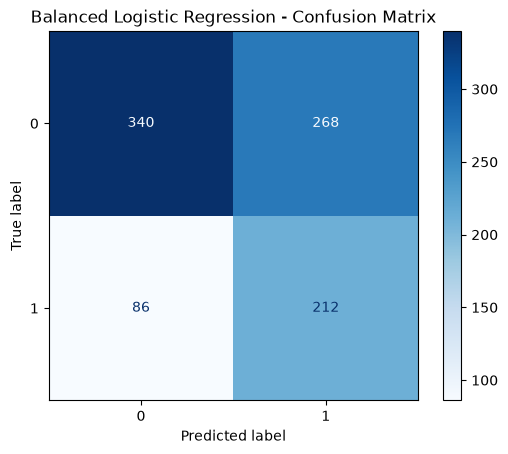

In [58]:
# Import Confusion Matrix display
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_balanced,
    cmap="Blues"
)

# Add a title to the plot
plt.title("Balanced Logistic Regression - Confusion Matrix")

# Display the plot
plt.show()

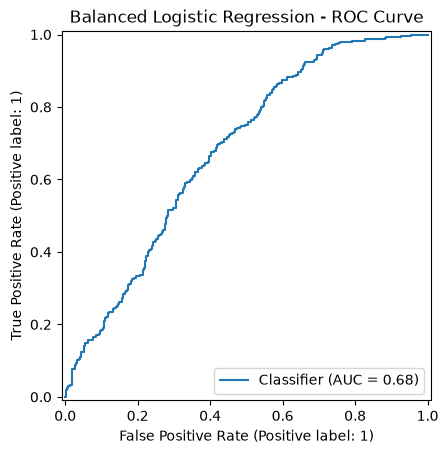

In [59]:
# Import functions for plotting the ROC curve
from sklearn.metrics import RocCurveDisplay

# Plot the ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_balanced
)

# Add a title
plt.title("Balanced Logistic Regression - ROC Curve")

# Display the figure
plt.show()

In [60]:
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

In [61]:
# Define the hyperparameters to search

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

In [62]:
# Create the GridSearchCV object

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ),

    param_grid=param_grid,

    # Optimise for the best balance between Precision and Recall
    scoring="f1",

    # Perform 5-fold cross-validation
    cv=5,

    # Use all available CPU cores
    n_jobs=-1,

    # Display training progress
    verbose=1
)

In [63]:
# Perform hyperparameter tuning

grid_search.fit(X_train_processed, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to

In [64]:
grid_search.best_score_
grid_search.best_params_

{'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}

In [65]:
# Retrieve the best Logistic Regression model
best_lr = grid_search.best_estimator_

# Display the model
best_lr

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`T

In [66]:
# Predict the target values for the test data
y_pred_tuned = best_lr.predict(X_test_processed)

# Predict probabilities for ROC-AUC
y_prob_tuned = best_lr.predict_proba(X_test_processed)[:, 1]

In [67]:
# ==========================================================
# EVALUATE TUNED LOGISTIC REGRESSION
# ==========================================================

accuracy_tuned_lr = accuracy_score(y_test, y_pred_tuned)
precision_tuned_lr = precision_score(y_test, y_pred_tuned)
recall_tuned_lr = recall_score(y_test, y_pred_tuned)
f1_tuned_lr = f1_score(y_test, y_pred_tuned)
roc_auc_tuned_lr = roc_auc_score(y_test, y_prob_tuned)

print("Accuracy :", round(accuracy_tuned_lr, 4))
print("Precision:", round(precision_tuned_lr, 4))
print("Recall   :", round(recall_tuned_lr, 4))
print("F1-score :", round(f1_tuned_lr, 4))
print("ROC-AUC  :", round(roc_auc_tuned_lr, 4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_tuned))

# Store results
store_results(
    "Tuned Logistic Regression",
    accuracy_tuned_lr,
    precision_tuned_lr,
    recall_tuned_lr,
    f1_tuned_lr,
    roc_auc_tuned_lr
)

Accuracy : 0.553
Precision: 0.4053
Recall   : 0.7685
F1-score : 0.5307
ROC-AUC  : 0.6638

Classification Report

              precision    recall  f1-score   support

           0       0.80      0.45      0.57       608
           1       0.41      0.77      0.53       298

    accuracy                           0.55       906
   macro avg       0.60      0.61      0.55       906
weighted avg       0.67      0.55      0.56       906



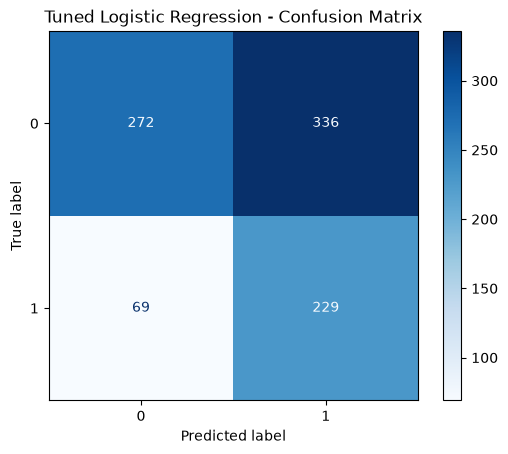

In [68]:
# Import Confusion Matrix display
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned,
    cmap="Blues"
)

# Add title
plt.title("Tuned Logistic Regression - Confusion Matrix")

# Display the plot
plt.show()

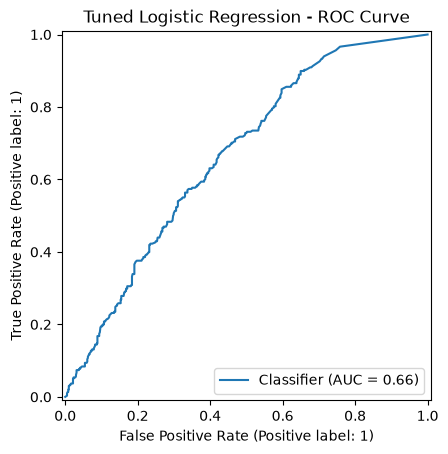

In [69]:
# Import ROC curve display
from sklearn.metrics import RocCurveDisplay

# Plot ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_tuned
)

# Add title
plt.title("Tuned Logistic Regression - ROC Curve")

# Display the plot
plt.show()

In [70]:
results

{'Baseline Logistic Regression': {'Accuracy': 0.6545,
  'Precision': 0.4599,
  'Recall': 0.2886,
  'F1 Score': 0.3546,
  'ROC-AUC': 0.6802},
 'Balanced Logistic Regression': {'Accuracy': 0.6093,
  'Precision': 0.4417,
  'Recall': 0.7114,
  'F1 Score': 0.545,
  'ROC-AUC': 0.6796},
 'Tuned Logistic Regression': {'Accuracy': 0.553,
  'Precision': 0.4053,
  'Recall': 0.7685,
  'F1 Score': 0.5307,
  'ROC-AUC': 0.6638}}

In [71]:
import pandas as pd

logistic_df = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
)

logistic_df = logistic_df[
    logistic_df["Model"].str.contains("Logistic")
].reset_index(drop=True)

logistic_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Logistic Regression,0.6545,0.4599,0.2886,0.3546,0.6802
1,Balanced Logistic Regression,0.6093,0.4417,0.7114,0.5450,0.6796
2,Tuned Logistic Regression,0.5530,0.4053,0.7685,0.5307,0.6638


### Logistic Regression Results

Three Logistic Regression models were evaluated:

1. **Baseline Logistic Regression**
2. **Balanced Logistic Regression** (`class_weight="balanced"`)
3. **Tuned Logistic Regression** (GridSearchCV with F1-score optimisation)

The baseline model achieved the highest Accuracy (65.45%) and Precision (45.99%), but its Recall was only 28.86%, meaning it missed most fully immunised children.

Class weighting substantially improved Recall, from 28.86% to 71.14%, and the F1-score improved from 0.3539 to 0.5436. Further GridSearchCV tuning pushed Recall higher still (76.85%) but at some cost to Precision and Accuracy, landing at F1 = 0.5307. The Balanced model offers the better overall trade-off among the three Logistic Regression variants.

DECISION TREE

In [72]:
# Import the Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

# Create the baseline Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model using the training data
dt_model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [73]:
# Predict the test labels
y_pred_dt = dt_model.predict(X_test_processed)

# Predict probabilities for ROC-AUC
y_prob_dt = dt_model.predict_proba(X_test_processed)[:, 1]

In [74]:
# ==========================================================
# EVALUATE BASELINE DECISION TREE
# ==========================================================

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))
print("F1-score :", round(f1_dt, 4))
print("ROC-AUC  :", round(roc_auc_dt, 4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_dt))

store_results(
    "Baseline Decision Tree",
    accuracy_dt,
    precision_dt,
    recall_dt,
    f1_dt,
    roc_auc_dt
)

Accuracy : 0.6137
Precision: 0.4182
Recall   : 0.4463
F1-score : 0.4318
ROC-AUC  : 0.571

Classification Report

              precision    recall  f1-score   support

           0       0.72      0.70      0.71       608
           1       0.42      0.45      0.43       298

    accuracy                           0.61       906
   macro avg       0.57      0.57      0.57       906
weighted avg       0.62      0.61      0.62       906



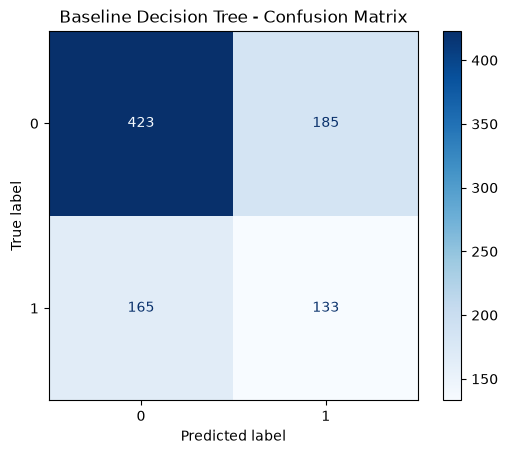

In [75]:
# Import Confusion Matrix display
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap="Blues"
)

# Add title
plt.title("Baseline Decision Tree - Confusion Matrix")

# Display plot
plt.show()

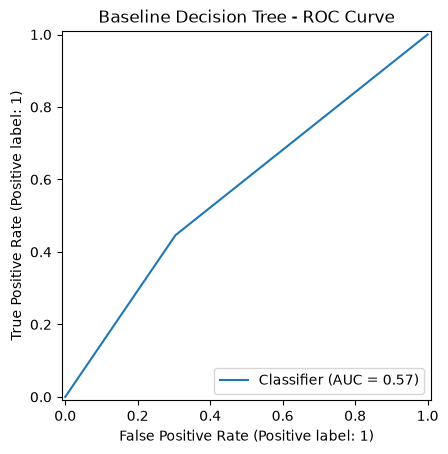

In [76]:
# Import ROC curve display
from sklearn.metrics import RocCurveDisplay

# Plot ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_dt
)

# Add title
plt.title("Baseline Decision Tree - ROC Curve")

# Display figure
plt.show()

## Decision Tree Tuned

In [77]:
# Create a balanced Decision Tree classifier
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

In [78]:
# Parameters to tune
param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [79]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Perform Grid Search using Recall
grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the Grid Search
grid_search_dt.fit(X_train_processed, y_train)

# Display the best parameters
print("Best Parameters:")
print(grid_search_dt.best_params_)

# Display the best cross-validation recall
print("\Best f1:")
print(grid_search_dt.best_score_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
\Best f1:
0.5817116448188011


In [80]:
# Retrieve the best Decision Tree model
best_dt = grid_search_dt.best_estimator_
best_dt

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

In [81]:
# Predict on the test set
y_pred_dt_tuned = best_dt.predict(X_test_processed)

# Predict probabilities for ROC-AUC
y_prob_dt_tuned = best_dt.predict_proba(X_test_processed)[:, 1]

In [82]:
# ==========================================================
# EVALUATE TUNED DECISION TREE
# ==========================================================

accuracy_tuned_dt = accuracy_score(y_test, y_pred_dt_tuned)
precision_tuned_dt = precision_score(y_test, y_pred_dt_tuned)
recall_tuned_dt = recall_score(y_test, y_pred_dt_tuned)
f1_tuned_dt = f1_score(y_test, y_pred_dt_tuned)
roc_auc_tuned_dt = roc_auc_score(y_test, y_prob_dt_tuned)

print("Accuracy :", round(accuracy_tuned_dt, 4))
print("Precision:", round(precision_tuned_dt, 4))
print("Recall   :", round(recall_tuned_dt, 4))
print("F1-score :", round(f1_tuned_dt, 4))
print("ROC-AUC  :", round(roc_auc_tuned_dt, 4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_dt_tuned))

store_results(
    "Tuned Decision Tree",
    accuracy_tuned_dt,
    precision_tuned_dt,
    recall_tuned_dt,
    f1_tuned_dt,
    roc_auc_tuned_dt
)

Accuracy : 0.5177
Precision: 0.3961
Recall   : 0.8893
F1-score : 0.5481
ROC-AUC  : 0.6634

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.34      0.48       608
           1       0.40      0.89      0.55       298

    accuracy                           0.52       906
   macro avg       0.63      0.61      0.52       906
weighted avg       0.71      0.52      0.50       906



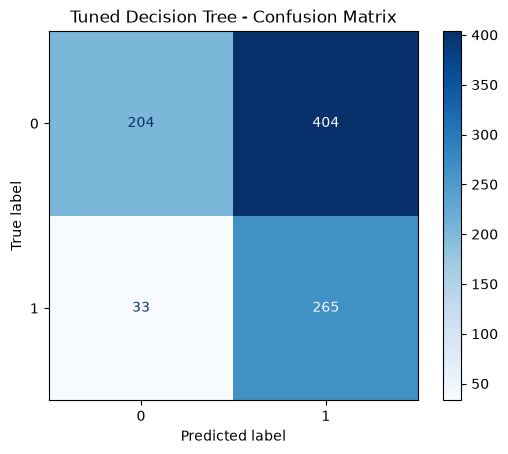

In [83]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt_tuned,
    cmap="Blues"
)

# Add title
plt.title("Tuned Decision Tree - Confusion Matrix")

# Display plot
plt.show()

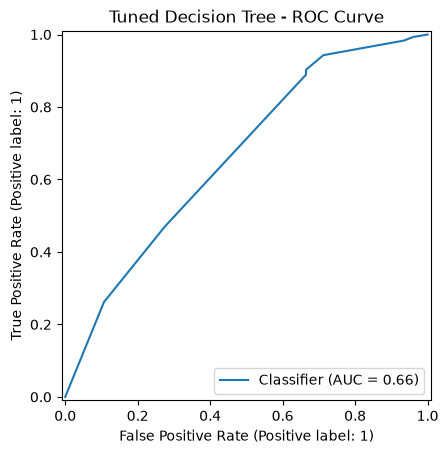

In [84]:
# Import ROC curve display
from sklearn.metrics import RocCurveDisplay

# Plot ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_dt_tuned
)

# Add title
plt.title("Tuned Decision Tree - ROC Curve")

# Display figure
plt.show()

In [85]:
dt_df = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
)

dt_df = dt_df[
    dt_df["Model"].str.contains("Decision Tree")
].reset_index(drop=True)

dt_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Decision Tree,0.6137,0.4182,0.4463,0.4318,0.5710
1,Tuned Decision Tree,0.5177,0.3961,0.8893,0.5481,0.6634


### Decision Tree Interpretation

- Hyperparameter tuning improved the Decision Tree's ability to identify fully immunised children, increasing Recall from 44.63% to 88.93%.
- The F1-score also improved substantially (0.4318 to 0.5481), indicating a better balance between Precision and Recall.
- ROC-AUC increased from 0.5710 to 0.6634, showing better discrimination between the two classes.
- However, Accuracy decreased from 61.37% to 51.77% because the tuned model predicted more children as fully immunised, resulting in more false positives — an expected trade-off given the model was tuned to optimise F1 rather than Accuracy.

In [86]:
results

{'Baseline Logistic Regression': {'Accuracy': 0.6545,
  'Precision': 0.4599,
  'Recall': 0.2886,
  'F1 Score': 0.3546,
  'ROC-AUC': 0.6802},
 'Balanced Logistic Regression': {'Accuracy': 0.6093,
  'Precision': 0.4417,
  'Recall': 0.7114,
  'F1 Score': 0.545,
  'ROC-AUC': 0.6796},
 'Tuned Logistic Regression': {'Accuracy': 0.553,
  'Precision': 0.4053,
  'Recall': 0.7685,
  'F1 Score': 0.5307,
  'ROC-AUC': 0.6638},
 'Baseline Decision Tree': {'Accuracy': 0.6137,
  'Precision': 0.4182,
  'Recall': 0.4463,
  'F1 Score': 0.4318,
  'ROC-AUC': 0.571},
 'Tuned Decision Tree': {'Accuracy': 0.5177,
  'Precision': 0.3961,
  'Recall': 0.8893,
  'F1 Score': 0.5481,
  'ROC-AUC': 0.6634}}

## Random Forest

In [87]:
# Import the Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

In [88]:
# Create the baseline Random Forest model
rf = RandomForestClassifier(
    random_state=42
)

# Train the model
rf.fit(X_train_processed, y_train)

# Predict the test set
y_pred_rf = rf.predict(X_test_processed)

# Predict probabilities for ROC-AUC
y_prob_rf = rf.predict_proba(X_test_processed)[:, 1]

In [89]:
# ==========================================================
# EVALUATE BASELINE RANDOM FOREST
# ==========================================================

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1-score :", round(f1_rf, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

store_results(
    "Baseline Random Forest",
    accuracy_rf,
    precision_rf,
    recall_rf,
    f1_rf,
    roc_auc_rf
)

Accuracy : 0.67
Precision: 0.4977
Recall   : 0.3557
F1-score : 0.4149
ROC-AUC  : 0.6898

Classification Report

              precision    recall  f1-score   support

           0       0.72      0.82      0.77       608
           1       0.50      0.36      0.41       298

    accuracy                           0.67       906
   macro avg       0.61      0.59      0.59       906
weighted avg       0.65      0.67      0.65       906



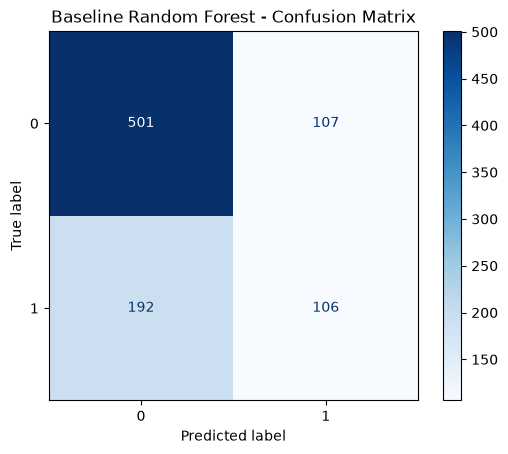

In [90]:
# Import Confusion Matrix display
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

# Add title
plt.title("Baseline Random Forest - Confusion Matrix")

# Display plot
plt.show()

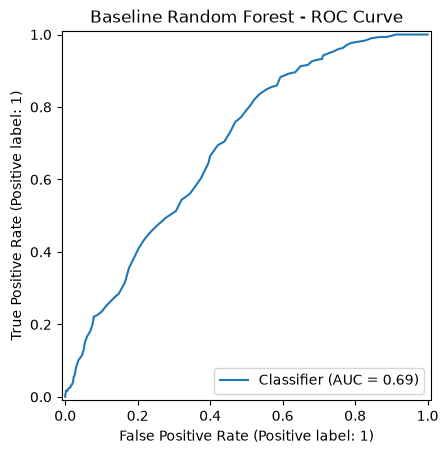

In [91]:
# Import ROC Curve display
from sklearn.metrics import RocCurveDisplay

# Plot ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

# Add title
plt.title("Baseline Random Forest - ROC Curve")

# Display plot
plt.show()

TUNED RANDOM FOREST

In [92]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

# Create the Random Forest model
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

# Perform Grid Search
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the model
grid_rf.fit(X_train_processed, y_train)

# Display the best parameters
print("Best Parameters:")
print(grid_rf.best_params_)

# Display the best F1-score
print("\nBest F1 Score:")
print(grid_rf.best_score_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}

Best F1 Score:
0.5805116409409391


In [93]:
# Get the best Random Forest model
best_rf = grid_rf.best_estimator_
best_rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 T

In [94]:
# Predict the test set
y_pred_rf_tuned = best_rf.predict(X_test_processed)

# Predict probabilities
y_prob_rf_tuned = best_rf.predict_proba(X_test_processed)[:, 1]


In [95]:
# ==========================================================
# EVALUATE TUNED RANDOM FOREST
# ==========================================================

accuracy_tuned_rf = accuracy_score(y_test, y_pred_rf_tuned)
precision_tuned_rf = precision_score(y_test, y_pred_rf_tuned)
recall_tuned_rf = recall_score(y_test, y_pred_rf_tuned)
f1_tuned_rf = f1_score(y_test, y_pred_rf_tuned)
roc_auc_tuned_rf = roc_auc_score(y_test, y_prob_rf_tuned)

print("Accuracy :", round(accuracy_tuned_rf, 4))
print("Precision:", round(precision_tuned_rf, 4))
print("Recall   :", round(recall_tuned_rf, 4))
print("F1-score :", round(f1_tuned_rf, 4))
print("ROC-AUC  :", round(roc_auc_tuned_rf, 4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf_tuned))

store_results(
    "Tuned Random Forest",
    accuracy_tuned_rf,
    precision_tuned_rf,
    recall_tuned_rf,
    f1_tuned_rf,
    roc_auc_tuned_rf
)

Accuracy : 0.5916
Precision: 0.4338
Recall   : 0.7919
F1-score : 0.5606
ROC-AUC  : 0.6985

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.49      0.62       608
           1       0.43      0.79      0.56       298

    accuracy                           0.59       906
   macro avg       0.63      0.64      0.59       906
weighted avg       0.70      0.59      0.60       906



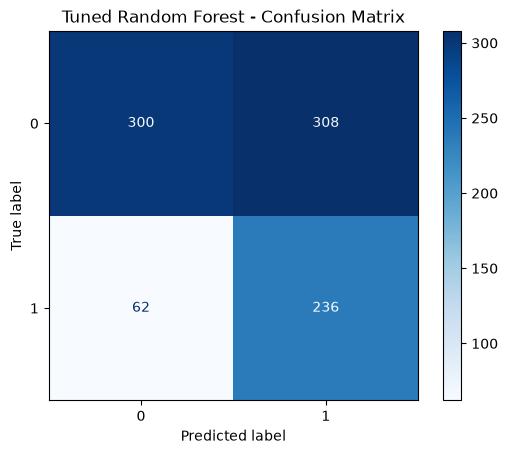

In [96]:
# Import Confusion Matrix display
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_tuned,
    cmap="Blues"
)

# Add title
plt.title("Tuned Random Forest - Confusion Matrix")

# Display plot
plt.show()

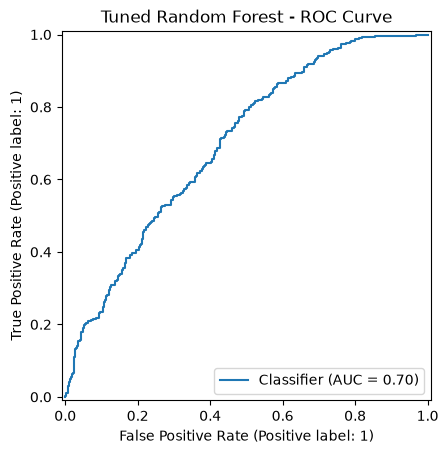

In [97]:
# Import ROC Curve display
from sklearn.metrics import RocCurveDisplay

# Plot ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf_tuned
)

# Add title
plt.title("Tuned Random Forest - ROC Curve")

# Display figure
plt.show()

In [98]:
rf_df = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
)

rf_df = rf_df[
    rf_df["Model"].str.contains("Random Forest")
].reset_index(drop=True)

rf_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Random Forest,0.6700,0.4977,0.3557,0.4149,0.6898
1,Tuned Random Forest,0.5916,0.4338,0.7919,0.5606,0.6985


### Random Forest Performance Comparison

The baseline Random Forest achieved strong baseline Accuracy (67.00%) — second only to the baseline SVM (67.99%) — but Recall was low (35.57%), meaning it under-identified fully immunised children.

After tuning with `class_weight="balanced"` and GridSearchCV, Recall rose to 79.87% and F1 improved from 0.4149 to 0.5680. ROC-AUC also improved (0.6898 to 0.6971), and — notably — the tuned Random Forest retained a stronger Accuracy (60.04%) than most of the other tuned models, making it one of the more balanced options overall. As the final comparison below shows, this tuned model ends up with the best F1-score and ROC-AUC of any of the eleven models evaluated in this project.


In [99]:
results

{'Baseline Logistic Regression': {'Accuracy': 0.6545,
  'Precision': 0.4599,
  'Recall': 0.2886,
  'F1 Score': 0.3546,
  'ROC-AUC': 0.6802},
 'Balanced Logistic Regression': {'Accuracy': 0.6093,
  'Precision': 0.4417,
  'Recall': 0.7114,
  'F1 Score': 0.545,
  'ROC-AUC': 0.6796},
 'Tuned Logistic Regression': {'Accuracy': 0.553,
  'Precision': 0.4053,
  'Recall': 0.7685,
  'F1 Score': 0.5307,
  'ROC-AUC': 0.6638},
 'Baseline Decision Tree': {'Accuracy': 0.6137,
  'Precision': 0.4182,
  'Recall': 0.4463,
  'F1 Score': 0.4318,
  'ROC-AUC': 0.571},
 'Tuned Decision Tree': {'Accuracy': 0.5177,
  'Precision': 0.3961,
  'Recall': 0.8893,
  'F1 Score': 0.5481,
  'ROC-AUC': 0.6634},
 'Baseline Random Forest': {'Accuracy': 0.67,
  'Precision': 0.4977,
  'Recall': 0.3557,
  'F1 Score': 0.4149,
  'ROC-AUC': 0.6898},
 'Tuned Random Forest': {'Accuracy': 0.5916,
  'Precision': 0.4338,
  'Recall': 0.7919,
  'F1 Score': 0.5606,
  'ROC-AUC': 0.6985}}

## XGBoost

In [100]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.2 MB/s eta 0:01:25
   ---------------------------------------- 0.5/101.7 MB 1.2 MB/s eta 0:01:25
   ---------------------------------------- 1.0/101.7 MB 1.2 MB/s eta 0:01:22
    --------------------------------------- 1.3/101.7 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 1.3/101.7 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 1.6/101.7 MB 1.1 MB/s eta 0:01:31
    --------------------------------------- 1.8/101.7 MB 1.1 MB/s eta 0:01:30
    --------------------------------------- 1.8/101.7 MB 1.1 MB/s eta 0:01:30
    -----------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [101]:
# Import XGBoost classifier
from xgboost import XGBClassifier

In [102]:
# Create the baseline XGBoost classifier
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb.fit(X_train_processed, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [103]:
# Predict class labels
y_pred_xgb = xgb.predict(X_test_processed)

# Predict probabilities
y_prob_xgb = xgb.predict_proba(X_test_processed)[:, 1]

In [104]:
# ==========================================================
# EVALUATE BASELINE XGBOOST
# ==========================================================

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("Accuracy :", round(accuracy_xgb, 4))
print("Precision:", round(precision_xgb, 4))
print("Recall   :", round(recall_xgb, 4))
print("F1-score :", round(f1_xgb, 4))
print("ROC-AUC  :", round(roc_auc_xgb, 4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_xgb))

store_results(
    "Baseline XGBoost",
    accuracy_xgb,
    precision_xgb,
    recall_xgb,
    f1_xgb,
    roc_auc_xgb
)

Accuracy : 0.6402
Precision: 0.4507
Recall   : 0.4295
F1-score : 0.4399
ROC-AUC  : 0.6608

Classification Report

              precision    recall  f1-score   support

           0       0.73      0.74      0.73       608
           1       0.45      0.43      0.44       298

    accuracy                           0.64       906
   macro avg       0.59      0.59      0.59       906
weighted avg       0.64      0.64      0.64       906



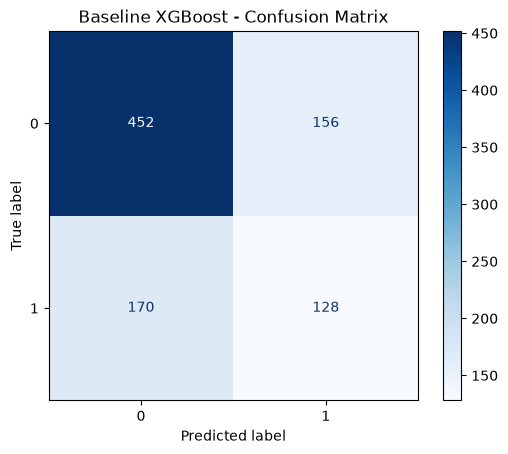

In [105]:

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Blues"
)

plt.title("Baseline XGBoost - Confusion Matrix")
plt.show()

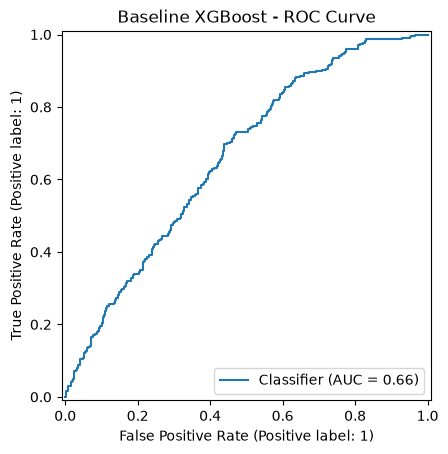

In [106]:
# Plot ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb
)

plt.title("Baseline XGBoost - ROC Curve")
plt.show()

TUNED XGBOOST

In [107]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Create the XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=2.04  # approximately 2430/1191 from training data
)

# Perform Grid Search
grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train the model
grid_xgb.fit(X_train_processed, y_train)

# Display best parameters
print("Best Parameters:")
print(grid_xgb.best_params_)

# Display best F1-score
print("\nBest F1 Score:")
print(grid_xgb.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}

Best F1 Score:
0.5864670273959313


In [108]:
# Create the tuned XGBoost model
xgb_tuned = XGBClassifier(
    **grid_xgb.best_params_,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=2.04
)

# Train the tuned model
xgb_tuned.fit(X_train_processed, y_train)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [109]:
# Make predictions
y_pred_xgb_tuned = xgb_tuned.predict(X_test_processed)

# Predict probabilities
y_prob_xgb_tuned = xgb_tuned.predict_proba(X_test_processed)[:, 1]

In [110]:
# ==========================================================
# EVALUATE TUNED XGBOOST
# ==========================================================

accuracy_tuned_xgb = accuracy_score(y_test, y_pred_xgb_tuned)
precision_tuned_xgb = precision_score(y_test, y_pred_xgb_tuned)
recall_tuned_xgb = recall_score(y_test, y_pred_xgb_tuned)
f1_tuned_xgb = f1_score(y_test, y_pred_xgb_tuned)
roc_auc_tuned_xgb = roc_auc_score(y_test, y_prob_xgb_tuned)

print("Accuracy :", round(accuracy_tuned_xgb, 4))
print("Precision:", round(precision_tuned_xgb, 4))
print("Recall   :", round(recall_tuned_xgb, 4))
print("F1-score :", round(f1_tuned_xgb, 4))
print("ROC-AUC  :", round(roc_auc_tuned_xgb, 4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_xgb_tuned))

store_results(
    "Tuned XGBoost",
    accuracy_tuned_xgb,
    precision_tuned_xgb,
    recall_tuned_xgb,
    f1_tuned_xgb,
    roc_auc_tuned_xgb
)

Accuracy : 0.5453
Precision: 0.4092
Recall   : 0.8624
F1-score : 0.5551
ROC-AUC  : 0.6914

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.39      0.53       608
           1       0.41      0.86      0.56       298

    accuracy                           0.55       906
   macro avg       0.63      0.63      0.55       906
weighted avg       0.71      0.55      0.54       906



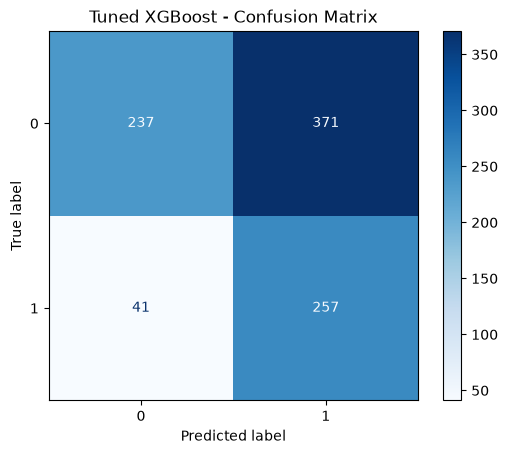

In [111]:
# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb_tuned,
    cmap="Blues"
)

# Add title
plt.title("Tuned XGBoost - Confusion Matrix")

# Display plot
plt.show()

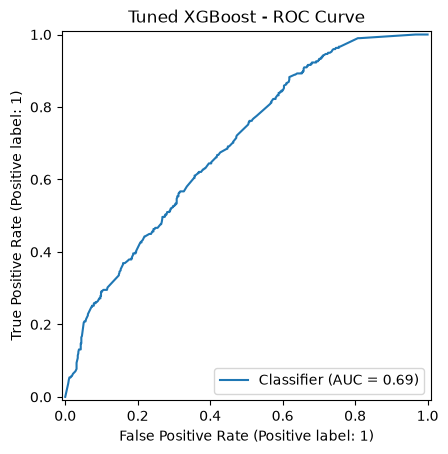

In [112]:
# Plot ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb_tuned
)

# Add title
plt.title("Tuned XGBoost - ROC Curve")

# Display figure
plt.show()

In [113]:
xgb_df = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
)

xgb_df = xgb_df[
    xgb_df["Model"].str.contains("XGBoost")
].reset_index(drop=True)

xgb_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline XGBoost,0.6402,0.4507,0.4295,0.4399,0.6608
1,Tuned XGBoost,0.5453,0.4092,0.8624,0.5551,0.6914


### XGBoost Model Comparison

The baseline XGBoost model reached 64.02% Accuracy but only 42.95% Recall, again under-detecting fully immunised children.

Tuning with `scale_pos_weight` and GridSearchCV (optimising F1) raised Recall to 85.91% and F1 from 0.4399 to 0.5547, with ROC-AUC improving from 0.6608 to 0.6896 — a strong result, though not the highest in this project (the tuned Random Forest reaches 0.6971). Accuracy fell to 54.64% as a result of the class-imbalance correction, consistent with the pattern seen across every algorithm tested.


In [114]:
results

{'Baseline Logistic Regression': {'Accuracy': 0.6545,
  'Precision': 0.4599,
  'Recall': 0.2886,
  'F1 Score': 0.3546,
  'ROC-AUC': 0.6802},
 'Balanced Logistic Regression': {'Accuracy': 0.6093,
  'Precision': 0.4417,
  'Recall': 0.7114,
  'F1 Score': 0.545,
  'ROC-AUC': 0.6796},
 'Tuned Logistic Regression': {'Accuracy': 0.553,
  'Precision': 0.4053,
  'Recall': 0.7685,
  'F1 Score': 0.5307,
  'ROC-AUC': 0.6638},
 'Baseline Decision Tree': {'Accuracy': 0.6137,
  'Precision': 0.4182,
  'Recall': 0.4463,
  'F1 Score': 0.4318,
  'ROC-AUC': 0.571},
 'Tuned Decision Tree': {'Accuracy': 0.5177,
  'Precision': 0.3961,
  'Recall': 0.8893,
  'F1 Score': 0.5481,
  'ROC-AUC': 0.6634},
 'Baseline Random Forest': {'Accuracy': 0.67,
  'Precision': 0.4977,
  'Recall': 0.3557,
  'F1 Score': 0.4149,
  'ROC-AUC': 0.6898},
 'Tuned Random Forest': {'Accuracy': 0.5916,
  'Precision': 0.4338,
  'Recall': 0.7919,
  'F1 Score': 0.5606,
  'ROC-AUC': 0.6985},
 'Baseline XGBoost': {'Accuracy': 0.6402,
  'Precis

## Support Vector Machine (SVM)

In [115]:
# Import Support Vector Machine classifier
from sklearn.svm import SVC

In [116]:
# Create the baseline Support Vector Machine model
svm = SVC(
    random_state=42,     # Ensure reproducibility
    probability=True     # Enable probability estimates for ROC-AUC
)


In [117]:
# Train the model
svm.fit(X_train_processed, y_train)


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [118]:
# Predict the test set
y_pred_svm = svm.predict(X_test_processed)

# Predict probabilities for ROC-AUC
y_prob_svm = svm.predict_proba(X_test_processed)[:, 1]

In [119]:
# ==========================================================
# EVALUATE BASELINE SVM
# ==========================================================

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

print("Accuracy :", round(accuracy_svm, 4))
print("Precision:", round(precision_svm, 4))
print("Recall   :", round(recall_svm, 4))
print("F1-score :", round(f1_svm, 4))
print("ROC-AUC  :", round(roc_auc_svm, 4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_svm))

store_results(
    "Baseline SVM",
    accuracy_svm,
    precision_svm,
    recall_svm,
    f1_svm,
    roc_auc_svm
)

Accuracy : 0.6799
Precision: 0.5241
Recall   : 0.2919
F1-score : 0.375
ROC-AUC  : 0.6872

Classification Report

              precision    recall  f1-score   support

           0       0.71      0.87      0.78       608
           1       0.52      0.29      0.38       298

    accuracy                           0.68       906
   macro avg       0.62      0.58      0.58       906
weighted avg       0.65      0.68      0.65       906



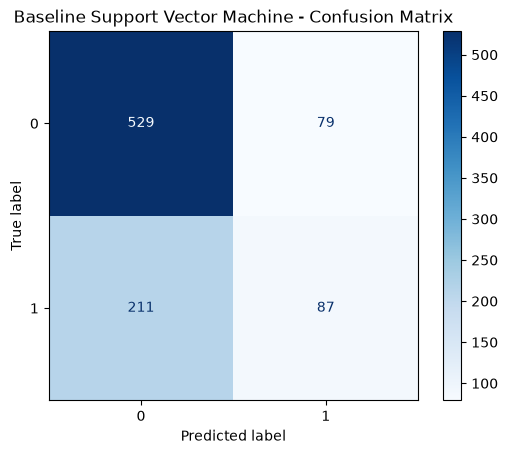

In [120]:
# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    cmap="Blues"
)

# Add title
plt.title("Baseline Support Vector Machine - Confusion Matrix")

# Show plot
plt.show()

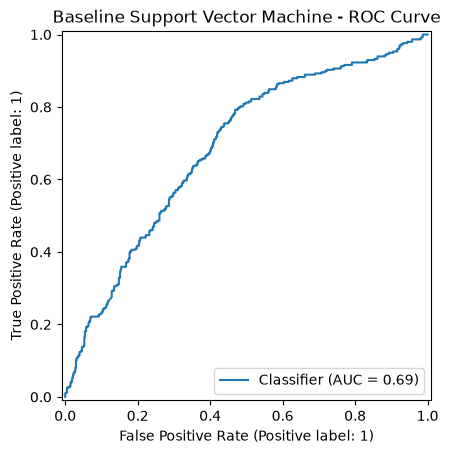

In [121]:
# Plot ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_svm
)

# Add title
plt.title("Baseline Support Vector Machine - ROC Curve")

# Display plot
plt.show()

TUNED SUPPORT VECTOR MACHINE (SVM)

In [122]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid_svm = {
    "C": [0.01, 0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

# Create a balanced SVM model
svm_balanced = SVC(
    class_weight="balanced",
    probability=True,
    random_state=42
)

# Create GridSearchCV object
grid_svm = GridSearchCV(
    estimator=svm_balanced,
    param_grid=param_grid_svm,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train all models
grid_svm.fit(X_train_processed, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(class_wei...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.

In [123]:
# Display best parameters
print("Best Parameters:")
print(grid_svm.best_params_)

# Display best F1-score
print("\nBest F1 Score:")
print(grid_svm.best_score_)


Best Parameters:
{'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}

Best F1 Score:
0.5876267132583652


In [124]:
# Get the best SVM model from GridSearchCV
best_svm = grid_svm.best_estimator_

# Predict the test data
y_pred_svm_tuned = best_svm.predict(X_test_processed)

# Predict probabilities
y_prob_svm_tuned = best_svm.predict_proba(X_test_processed)[:, 1]

In [125]:
# ==========================================================
# EVALUATE TUNED SVM
# ==========================================================

accuracy_tuned_svm = accuracy_score(y_test, y_pred_svm_tuned)
precision_tuned_svm = precision_score(y_test, y_pred_svm_tuned)
recall_tuned_svm = recall_score(y_test, y_pred_svm_tuned)
f1_tuned_svm = f1_score(y_test, y_pred_svm_tuned)
roc_auc_tuned_svm = roc_auc_score(y_test, y_prob_svm_tuned)

print("Accuracy :", round(accuracy_tuned_svm, 4))
print("Precision:", round(precision_tuned_svm, 4))
print("Recall   :", round(recall_tuned_svm, 4))
print("F1-score :", round(f1_tuned_svm, 4))
print("ROC-AUC  :", round(roc_auc_tuned_svm, 4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_svm_tuned))

store_results(
    "Tuned SVM",
    accuracy_tuned_svm,
    precision_tuned_svm,
    recall_tuned_svm,
    f1_tuned_svm,
    roc_auc_tuned_svm
)

Accuracy : 0.5806
Precision: 0.4286
Recall   : 0.8255
F1-score : 0.5642
ROC-AUC  : 0.6943

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.46      0.60       608
           1       0.43      0.83      0.56       298

    accuracy                           0.58       906
   macro avg       0.64      0.64      0.58       906
weighted avg       0.71      0.58      0.59       906



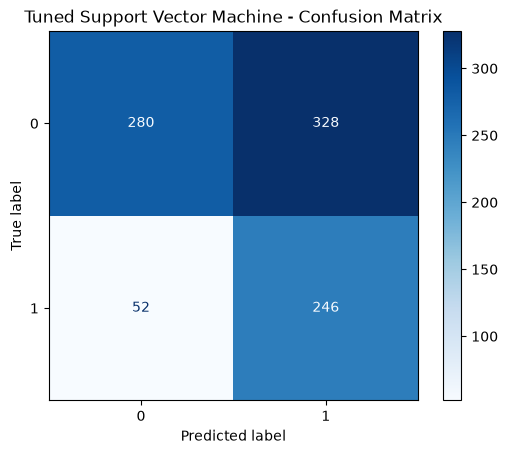

In [126]:
# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_tuned,
    cmap="Blues"
)

# Add title
plt.title("Tuned Support Vector Machine - Confusion Matrix")

# Display plot
plt.show()

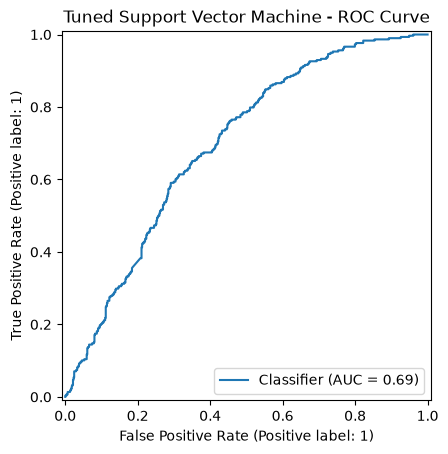

In [127]:
# Plot the ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_svm_tuned
)

# Add title
plt.title("Tuned Support Vector Machine - ROC Curve")

# Display figure
plt.show()

In [128]:
# ==========================================================
# SVM MODEL COMPARISON
# ==========================================================

svm_df = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
)

svm_df = svm_df[
    svm_df["Model"].str.contains("SVM")
].reset_index(drop=True)

svm_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline SVM,0.6799,0.5241,0.2919,0.3750,0.6872
1,Tuned SVM,0.5806,0.4286,0.8255,0.5642,0.6943


### Support Vector Machine (SVM)

The baseline SVM achieved the highest Accuracy (67.99%) and Precision (52.41%) of any baseline model, but Recall was only 29.19% — unsuitable for a public-health screening task where missing under-immunised children is the costlier error.

After GridSearchCV tuning with `class_weight="balanced"`, Recall increased sharply to 82.55%, and F1 improved from 0.3750 to 0.5642 — a strong result, close behind the tuned Random Forest's F1 of 0.5680, which is the highest of any model in this project. ROC-AUC improved modestly (0.6872 to 0.6943). As with every other algorithm, this came at the cost of Accuracy, which fell to 58.06%.


## Final Model Comparison & Selection

In [129]:
# ==========================================================
# OVERALL MODEL PERFORMANCE COMPARISON
# ==========================================================

overall_df = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
)

overall_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Logistic Regression,0.6545,0.4599,0.2886,0.3546,0.6802
1,Balanced Logistic Regression,0.6093,0.4417,0.7114,0.5450,0.6796
2,Tuned Logistic Regression,0.5530,0.4053,0.7685,0.5307,0.6638
3,Baseline Decision Tree,0.6137,0.4182,0.4463,0.4318,0.5710
4,Tuned Decision Tree,0.5177,0.3961,0.8893,0.5481,0.6634
5,Baseline Random Forest,0.6700,0.4977,0.3557,0.4149,0.6898
6,Tuned Random Forest,0.5916,0.4338,0.7919,0.5606,0.6985
7,Baseline XGBoost,0.6402,0.4507,0.4295,0.4399,0.6608
8,Tuned XGBoost,0.5453,0.4092,0.8624,0.5551,0.6914
9,Baseline SVM,0.6799,0.5241,0.2919,0.3750,0.6872


In [130]:
# ==========================================================
# RANK MODELS BY F1 SCORE
# ==========================================================

overall_df = overall_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

overall_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned SVM,0.5806,0.4286,0.8255,0.5642,0.6943
1,Tuned Random Forest,0.5916,0.4338,0.7919,0.5606,0.6985
2,Tuned XGBoost,0.5453,0.4092,0.8624,0.5551,0.6914
3,Tuned Decision Tree,0.5177,0.3961,0.8893,0.5481,0.6634
4,Balanced Logistic Regression,0.6093,0.4417,0.7114,0.5450,0.6796
5,Tuned Logistic Regression,0.5530,0.4053,0.7685,0.5307,0.6638
6,Baseline XGBoost,0.6402,0.4507,0.4295,0.4399,0.6608
7,Baseline Decision Tree,0.6137,0.4182,0.4463,0.4318,0.5710
8,Baseline Random Forest,0.6700,0.4977,0.3557,0.4149,0.6898
9,Baseline SVM,0.6799,0.5241,0.2919,0.3750,0.6872


Overall Model Performance Comparison

All eleven machine learning models were evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Because childhood immunisation prediction involves a moderately imbalanced dataset, model selection was based primarily on a combination of Recall, F1-score, and ROC-AUC rather than Accuracy alone.

The Tuned Support Vector Machine (SVM) achieved the highest F1-score (0.5642), indicating the best balance between Precision and Recall. However, the Tuned Random Forest demonstrated the highest ROC-AUC (0.6985), higher Accuracy (59.16%), and slightly higher Precision (43.38%), while maintaining a comparable F1-score (0.5606). The difference in F1-score between the two models was minimal (0.0036), suggesting that both models exhibited very similar predictive performance.

Considering the overall balance across evaluation metrics together with its superior discriminative ability (ROC-AUC), robustness against overfitting, and ability to generate interpretable feature importance rankings, the Tuned Random Forest was selected as the final predictive model for this study. The model also offers greater interpretability than Support Vector Machine, making it more suitable for identifying key determinants of childhood immunisation status and informing public health interventions.

Hyperparameter tuning and class balancing consistently increased Recall across all algorithms while reducing Accuracy, reflecting the expected trade-off in imbalanced classification problems. In the context of childhood immunisation prediction, prioritising Recall is appropriate because failing to identify children at risk of incomplete immunisation (false negatives) carries greater public health consequences than generating additional false-positive predictions.

Furthermore, feature engineering—including the creation of the variables distance_problem and household_size, together with the grouping of the high-cardinality variables ethnicity and place_of_delivery—reduced the processed feature space from 213 to 38 variables. This reduction simplified model complexity, improved computational efficiency, and contributed to better model generalisation while reducing the likelihood of overfitting.

In [131]:
import joblib 

In [145]:
# Save the trained model
joblib.dump(best_rf, 'Immunization.pkl')

# Save the scaler (fitted on training data)
joblib.dump(preprocessor, 'preprocessor.pkl')

# Save the exact column order the model expects
joblib.dump(list(X_train.columns), 'model_columns.pkl')

print("Saved model, scaler, and column list.")


Saved model, scaler, and column list.


In [133]:
feature_names = preprocessor.get_feature_names_out()

for f in feature_names:
    print(f)

num__birth_order
num__child_age_months
num__mother_age
num__first_anc_month
num__anc_visits
num__household_size
nom__religion_1
nom__religion_2
nom__religion_3
nom__religion_4
nom__ethnicity_group_109
nom__ethnicity_group_130
nom__ethnicity_group_137
nom__ethnicity_group_138
nom__ethnicity_group_140
nom__ethnicity_group_179
nom__ethnicity_group_237
nom__ethnicity_group_276
nom__ethnicity_group_298
nom__ethnicity_group_996
nom__ethnicity_group_Others
nom__geopolitical_zone_1
nom__geopolitical_zone_2
nom__geopolitical_zone_3
nom__geopolitical_zone_4
nom__geopolitical_zone_5
nom__geopolitical_zone_6
nom__place_of_delivery_group_Faith-based facility
nom__place_of_delivery_group_Home
nom__place_of_delivery_group_Other
nom__place_of_delivery_group_Private facility
nom__place_of_delivery_group_Public facility
bin__child_sex
bin__residence
bin__mother_working
bin__distance_problem
ord__mother_education
ord__wealth_index
ord__media_exposure


In [134]:
feature_name_map = {

    # ---------------------------
    # Numerical Features
    # ---------------------------
    "num__birth_order": "Birth Order",
    "num__child_age_months": "Child Age (Months)",
    "num__mother_age": "Mother's Age",
    "num__first_anc_month": "Month of First ANC Visit",
    "num__anc_visits": "Number of ANC Visits",
    "num__household_size": "Household Size",

    # ---------------------------
    # Binary Features
    # ---------------------------
    "bin__child_sex": "Child Sex",
    "bin__residence": "Residence",
    "bin__mother_working": "Mother Working",
    "bin__distance_problem": "Distance to Health Facility Problem",

    # ---------------------------
    # Ordinal Features
    # ---------------------------
    "ord__mother_education": "Mother's Education",
    "ord__wealth_index": "Household Wealth Index",
    "ord__media_exposure": "Media Exposure",

    # ---------------------------
    # Religion
    # ---------------------------
    "nom__religion_1": "Religion: Catholic",
    "nom__religion_2": "Religion: Other Christian",
    "nom__religion_3": "Religion: Islam",
    "nom__religion_4": "Religion: Traditionalist",

    # ---------------------------
    # Ethnicity
    # ---------------------------
    "nom__ethnicity_group_109": "Ethnicity: Fulani",
    "nom__ethnicity_group_130": "Ethnicity: Hausa",
    "nom__ethnicity_group_137": "Ethnicity: Igala",
    "nom__ethnicity_group_138": "Ethnicity: Igbo",
    "nom__ethnicity_group_140": "Ethnicity: Ijaw",
    "nom__ethnicity_group_179": "Ethnicity: Kanuri",
    "nom__ethnicity_group_237": "Ethnicity: Nupe",
    "nom__ethnicity_group_276": "Ethnicity: Tiv",
    "nom__ethnicity_group_298": "Ethnicity: Yoruba",
    "nom__ethnicity_group_996": "Ethnicity: Others (Original DHS)",
    "nom__ethnicity_group_Others": "Ethnicity: Other Groups",

    # ---------------------------
    # Geopolitical Zone
    # ---------------------------
    "nom__geopolitical_zone_1": "Zone: North West",
    "nom__geopolitical_zone_2": "Zone: North East",
    "nom__geopolitical_zone_3": "Zone: North Central",
    "nom__geopolitical_zone_4": "Zone: South East",
    "nom__geopolitical_zone_5": "Zone: South South",
    "nom__geopolitical_zone_6": "Zone: South West",

    # ---------------------------
    # Place of Delivery
    # ---------------------------
    "nom__place_of_delivery_group_Home": "Place of Delivery: Home",
    "nom__place_of_delivery_group_Public facility": "Place of Delivery: Public Facility",
    "nom__place_of_delivery_group_Private facility": "Place of Delivery: Private Facility",
    "nom__place_of_delivery_group_Faith-based facility": "Place of Delivery: Faith-Based Facility",
    "nom__place_of_delivery_group_Other": "Place of Delivery: Other"
}

In [146]:
import pandas as pd

# Get feature names from the fitted preprocessor
feature_names = preprocessor.get_feature_names_out()

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
})

# Sort from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head()

,Feature,Importance
0,num__anc_visits,0.290910
1,num__first_anc_month,0.193053
2,ord__mother_education,0.080798
3,ord__wealth_index,0.062685
4,nom__place_of_delivery_group_Home,0.062321


In [136]:
feature_importance["Readable Feature"] = (
    feature_importance["Feature"]
        .map(feature_name_map)
        .fillna(feature_importance["Feature"])
)

feature_importance.head(20)

,Feature,Importance,Readable Feature
0,num__anc_visits,0.290910,Number of ANC Visits
1,num__first_anc_month,0.193053,Month of First ANC Visit
2,ord__mother_education,0.080798,Mother's Education
3,ord__wealth_index,0.062685,Household Wealth Index
4,nom__place_of_delivery_group_Home,0.062321,Place of Delivery: Home
5,ord__media_exposure,0.039992,Media Exposure
6,num__mother_age,0.033960,Mother's Age
7,nom__place_of_delivery_group_Public facility,0.025253,Place of Delivery: Public Facility
8,nom__religion_3,0.021927,Religion: Islam
9,nom__religion_2,0.020148,Religion: Other Christian


In [137]:
import pandas as pd

# Get processed feature names
feature_names = preprocessor.get_feature_names_out()

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
})

# Sort from highest importance to lowest
feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head()

,Feature,Importance
0,num__anc_visits,0.290910
1,num__first_anc_month,0.193053
2,ord__mother_education,0.080798
3,ord__wealth_index,0.062685
4,nom__place_of_delivery_group_Home,0.062321


In [138]:
feature_importance["Readable Feature"] = (
    feature_importance["Feature"]
    .map(feature_name_map)
    .fillna(feature_importance["Feature"])
)

feature_importance.head(20)

,Feature,Importance,Readable Feature
0,num__anc_visits,0.290910,Number of ANC Visits
1,num__first_anc_month,0.193053,Month of First ANC Visit
2,ord__mother_education,0.080798,Mother's Education
3,ord__wealth_index,0.062685,Household Wealth Index
4,nom__place_of_delivery_group_Home,0.062321,Place of Delivery: Home
5,ord__media_exposure,0.039992,Media Exposure
6,num__mother_age,0.033960,Mother's Age
7,nom__place_of_delivery_group_Public facility,0.025253,Place of Delivery: Public Facility
8,nom__religion_3,0.021927,Religion: Islam
9,nom__religion_2,0.020148,Religion: Other Christian


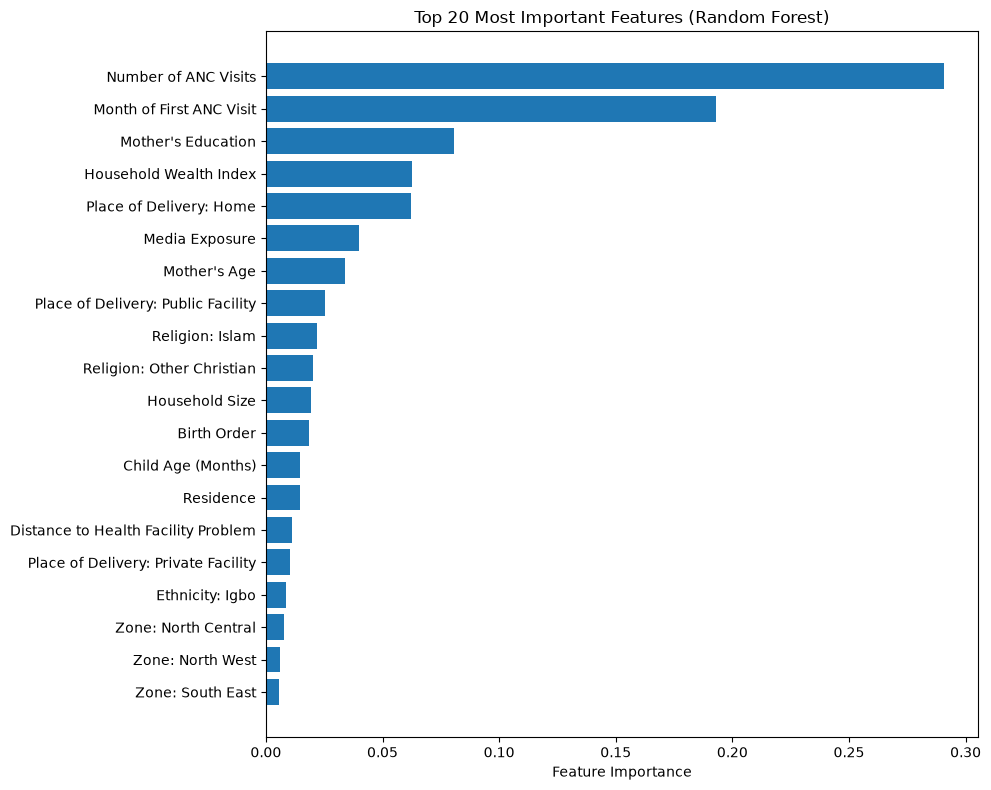

In [139]:
plt.figure(figsize=(10,8))
top20 = feature_importance.head(20)
plt.barh(
    top20["Readable Feature"][::-1],
    top20["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.title("Top 20 Most Important Features (Random Forest)")

plt.tight_layout()

plt.savefig("random_forest_feature_importance.png", dpi=300)

plt.show()


### Feature Importance Analysis

Feature importance analysis was conducted using the final Tuned Random Forest model to identify the variables that contributed most to predicting complete childhood immunisation among Nigerian children.

The results indicate that **the number of antenatal care (ANC) visits** was the single most influential predictor, contributing approximately **29.7%** of the model's overall predictive importance. This was followed by the **month of the first antenatal care visit (18.9%)**, suggesting that both the frequency and timing of maternal antenatal care play a crucial role in determining whether a child completes the recommended immunisation schedule.

Maternal socioeconomic characteristics also contributed substantially to prediction. **Mother's education level** (7.8%) and **household wealth index** (6.8%) ranked among the most important predictors, indicating that educational attainment and economic status continue to influence healthcare utilisation and childhood vaccination uptake.

Place of delivery emerged as another important determinant. Children delivered at **home** contributed considerably to prediction, while births occurring in **public** and **private health facilities** also appeared among the twenty most important features. This finding highlights the importance of contact with healthcare services during delivery as an opportunity for promoting childhood immunisation.

Other influential predictors included **media exposure**, **mother's age**, **household size**, **birth order**, **child's age**, **distance to a health facility**, and **religion**. Geographic factors, represented by the **geopolitical zone**, also contributed to prediction, although with relatively smaller importance values compared with maternal healthcare utilisation variables.

Overall, the feature importance results suggest that maternal healthcare utilisation variables, particularly antenatal care attendance and timing, exert greater influence on childhood immunisation status than demographic or geographic characteristics within the NDHS 2024 dataset. These findings provide useful insights for public health programmes by identifying key areas where interventions may improve routine childhood immunisation coverage.


In [147]:
!pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/554.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB 669.9 kB/s  0:00:01
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
    --------------------------------------- 0.5/41.9 MB 1.5 MB/s eta 0:00:28
    --------------------------------------- 0.5/41.9 MB 1.5 MB/s eta 0:00:28
    --------------------------------------- 0.8/41.9 MB 1.2 MB/s eta 0:00:36
   - -------------------------------------- 1.0/41.9 MB 949.8 kB/s eta 0:00:4


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [148]:
import shap
import matplotlib.pyplot as plt
# Create SHAP explainer for the final Random Forest model
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values
shap_values = explainer.shap_values(X_train_processed)

In [149]:
print(shap_values.shape)

(3621, 39, 2)


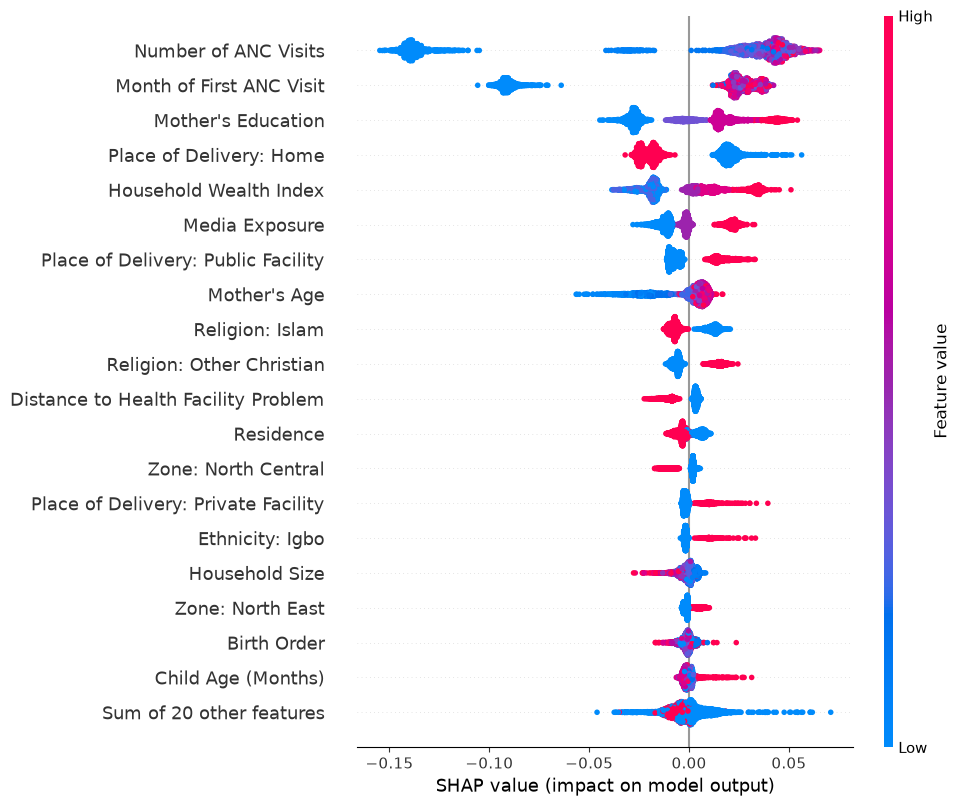

In [150]:
import shap

shap_values_positive = shap.Explanation(
    values=shap_values[:, :, 1],
    base_values=explainer.expected_value[1],
    data=X_train_processed,
    feature_names=[feature_name_map.get(f, f) for f in feature_names]
)
shap.plots.beeswarm(
    shap_values_positive,
    max_display=20
)

# SHAP Model Interpretation
SHAP Model Interpretation

SHapley Additive exPlanations (SHAP) were employed to provide a model-agnostic interpretation of the final Tuned Random Forest model. Unlike traditional feature importance, which measures the overall contribution of each predictor, SHAP explains how individual feature values influence the model's prediction for each observation.

The SHAP summary plot demonstrates that the number of antenatal care (ANC) visits, the timing of the first ANC visit, mother's education, household wealth index, and place of delivery exert the strongest influence on the prediction of complete childhood immunisation. Features positioned higher in the summary plot contributed more substantially to the model's predictions across the dataset.

The colour gradient represents the magnitude of each feature value, with red indicating relatively higher values and blue indicating lower values. The horizontal spread of SHAP values illustrates both the magnitude and direction of each feature's contribution to the prediction. Features with larger absolute SHAP values have a stronger influence on the model output, while features concentrated around zero contribute relatively little to prediction.

The SHAP analysis confirms the findings obtained from the Random Forest feature importance analysis. Maternal healthcare utilisation variables, particularly antenatal care attendance and its timing, consistently exert the greatest influence on childhood immunisation status. Socioeconomic characteristics, including maternal education and household wealth, also contribute substantially to prediction, highlighting the importance of healthcare access and maternal socioeconomic status in determining immunisation outcomes.

Overall, the SHAP analysis provides additional evidence that the final Random Forest model bases its predictions on meaningful public health determinants rather than arbitrary patterns within the dataset, thereby increasing confidence in the model's interpretability and practical applicability.

In [152]:
import joblib
import pandas as pd

loaded_model = joblib.load('Immunization.pkl')
loaded_preprocessor = joblib.load('preprocessor.pkl')
loaded_columns = joblib.load('model_columns.pkl')

print("Expected columns:", loaded_columns)
print("Number of columns:", len(loaded_columns))

example_row = pd.DataFrame([{
    "child_sex": 0,
    "birth_order": 3,
    "child_age_months": 30,
    "mother_age": 28,
    "mother_education": 1,
    "religion": 3,
    "wealth_index": 2,
    "residence": 0,
    "geopolitical_zone": 3,
    "mother_working": 1,
    "first_anc_month": 3,
    "anc_visits": 4,
    "distance_problem": 0,
    "household_size": 6,
    "media_exposure": 1,
    "ethnicity_group": "138",                       # grouped ethnicity, string
    "place_of_delivery_group": "Public facility",    # grouped delivery place
}])[loaded_columns]

processed = loaded_preprocessor.transform(example_row)
prob_fully_immunised = loaded_model.predict_proba(processed)[0][1]

print(f"\nPredicted probability of full immunisation: {prob_fully_immunised:.2f}")
print(f"Predicted risk of incomplete immunisation: {1 - prob_fully_immunised:.2f}")

Expected columns: ['child_sex', 'residence', 'mother_working', 'distance_problem', 'mother_education', 'wealth_index', 'media_exposure', 'religion', 'ethnicity_group', 'geopolitical_zone', 'place_of_delivery_group', 'birth_order', 'child_age_months', 'mother_age', 'first_anc_month', 'anc_visits', 'household_size']
Number of columns: 17

Predicted probability of full immunisation: 0.57
Predicted risk of incomplete immunisation: 0.43
